## load the data 

In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\tyagi\Downloads\train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# how big the data??

In [2]:
df.shape

(891, 12)

## How does the data look?

In [3]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
509,510,1,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
281,282,0,3,"Olsson, Mr. Nils Johan Goransson",male,28.0,0,0,347464,7.8542,NaN,S
500,501,0,3,"Calic, Mr. Petar",male,17.0,0,0,315086,8.6625,NaN,S
66,67,1,2,"Nye, Mrs. (Elizabeth Ramell)",female,29.0,0,0,C.A. 29395,10.5000,F33,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C


## What is the data type of cols?

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Are their any missing values??

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## How does the data look mathematically??

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Are their duplicate values??

In [7]:
df.duplicated().sum()

np.int64(0)

## How is the correlation between cols?

In [8]:
df.select_dtypes(include='number').corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [9]:
df.select_dtypes(include='number').corr()['Survived']

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

# Univariant Analysis

## Categorical Data

<Axes: xlabel='Survived', ylabel='count'>

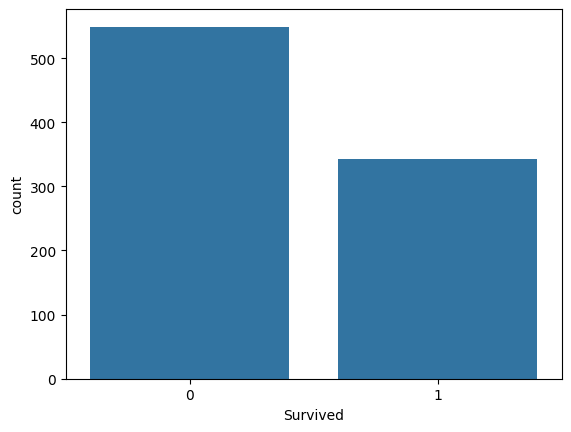

In [10]:
import seaborn as sns
sns.countplot(x='Survived',data=df)

<Axes: xlabel='Pclass', ylabel='count'>

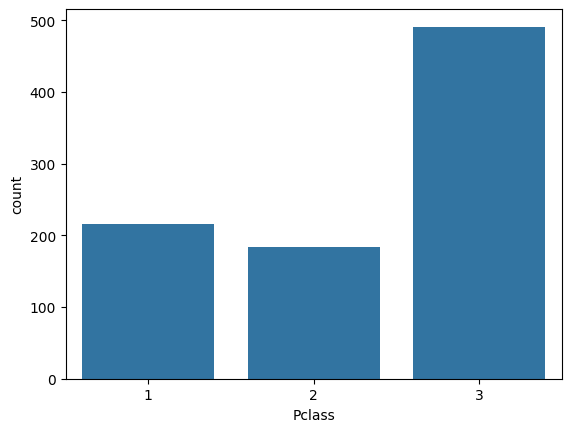

In [11]:
sns.countplot(x='Pclass',data=df)

<Axes: xlabel='Embarked', ylabel='count'>

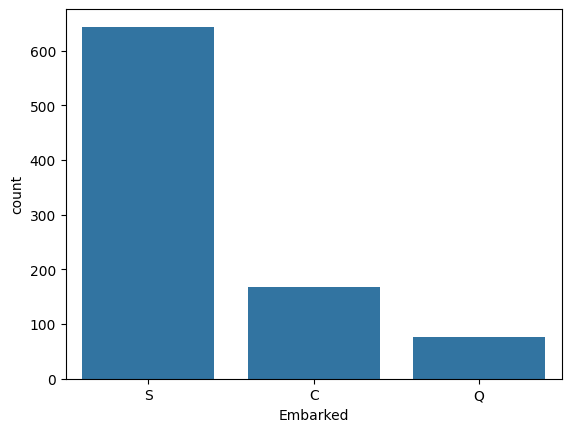

In [12]:
sns.countplot(x='Embarked',data=df)

<Axes: ylabel='count'>

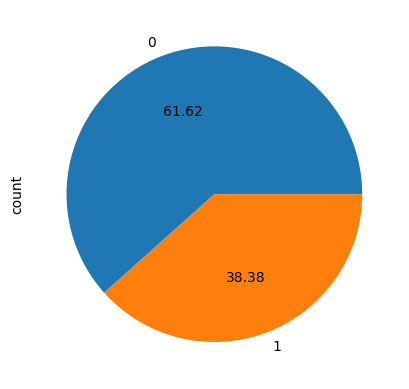

In [13]:
df['Survived'].value_counts().plot(kind='pie',autopct='%0.2f')

<Axes: xlabel='Age', ylabel='Count'>

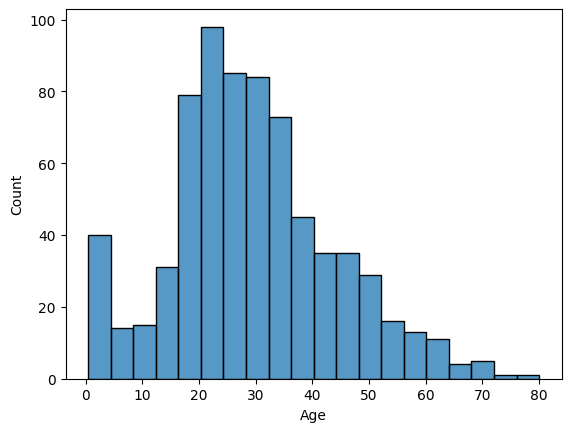

In [14]:
sns.histplot(x='Age',data=df)

C:\Users\tyagi\AppData\Local\Temp\ipykernel_17644\3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

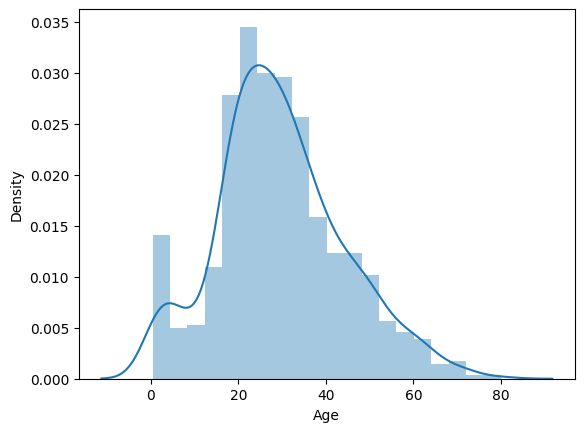

In [17]:
sns.distplot(df['Age'])

<Axes: ylabel='Age'>

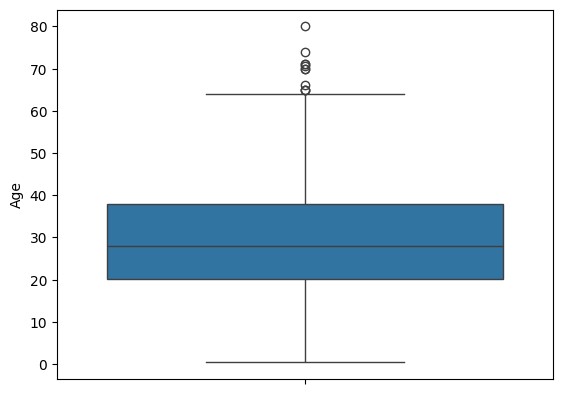

In [20]:
sns.boxplot(df['Age'])

<Axes: ylabel='SibSp'>

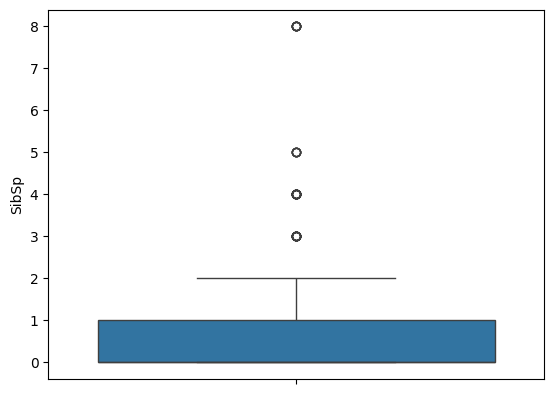

In [25]:
sns.boxplot(df['SibSp'])

In [26]:
df['SibSp'].skew()

np.float64(3.6953517271630565)

C:\Users\tyagi\AppData\Local\Temp\ipykernel_17644\1634579339.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['SibSp'])


<Axes: xlabel='SibSp', ylabel='Density'>

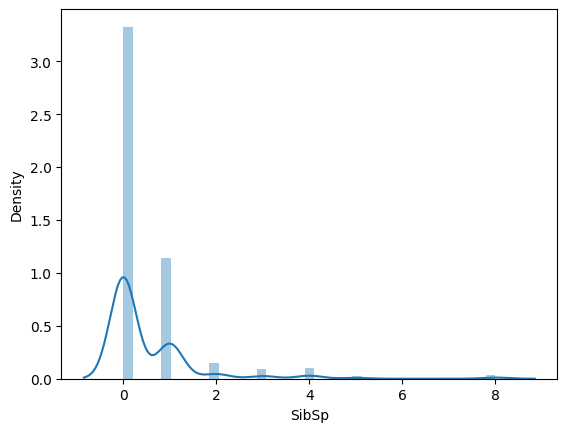

In [27]:
sns.distplot(df['SibSp'])

In [3]:
import seaborn as sns
tips=sns.load_dataset('tips')
tips.sample(5)

,total_bill,tip,sex,smoker,day,time,size
178,9.60,4.00,Female,Yes,Sun,Dinner,2
233,10.77,1.47,Male,No,Sat,Dinner,2
231,15.69,3.00,Male,Yes,Sat,Dinner,3
224,13.42,1.58,Male,Yes,Fri,Lunch,2
213,13.27,2.50,Female,Yes,Sat,Dinner,2


In [4]:
flight=sns.load_dataset('flights')
flight.sample(5)

,year,month,passengers
58,1953,Nov,180
105,1957,Oct,347
110,1958,Mar,362
92,1956,Sep,355
94,1956,Nov,271


In [5]:
iris=sns.load_dataset('iris')
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Bivariant Analysis

## numerical vs numerical

<Axes: xlabel='total_bill', ylabel='tip'>

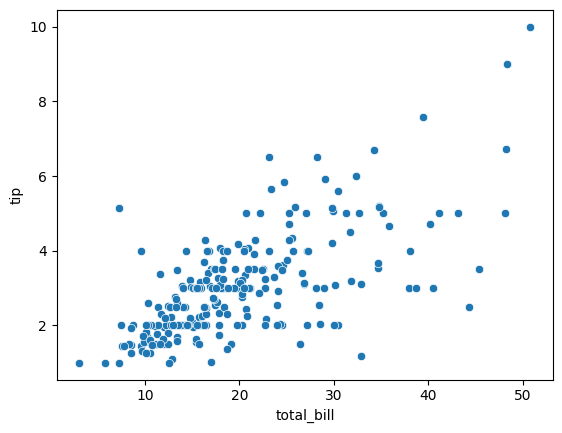

In [37]:
sns.scatterplot(x='total_bill',y='tip',data=tips)

### example of multivarinat analysis through scatter plot

<Axes: xlabel='total_bill', ylabel='tip'>

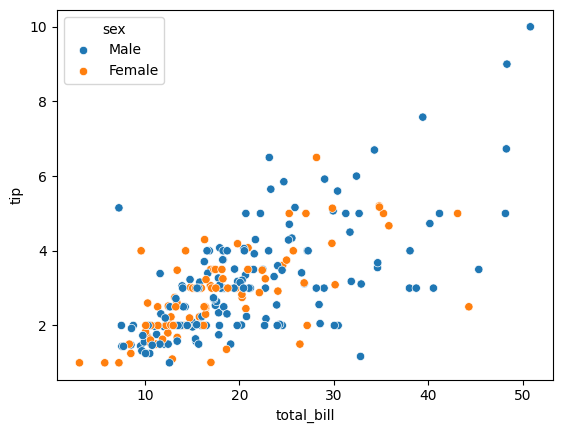

In [38]:
sns.scatterplot(x='total_bill',y='tip',data=tips,hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

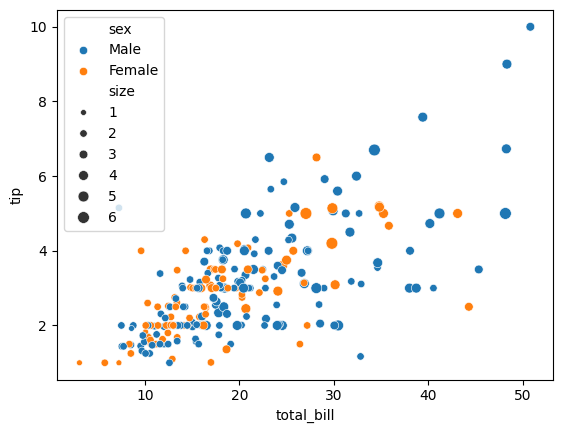

In [39]:
sns.scatterplot(x='total_bill',y='tip',data=tips,hue='sex',size='size')

## categorical vs Numerical

<Axes: xlabel='Pclass', ylabel='Fare'>

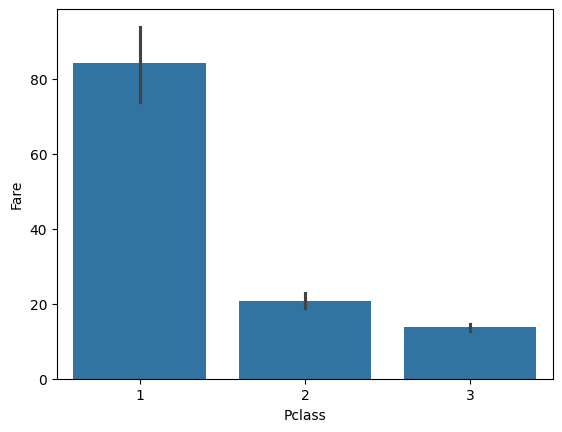

In [7]:
sns.barplot(x='Pclass',y='Fare',data=df)

### multivariant analysis

<Axes: xlabel='Pclass', ylabel='Fare'>

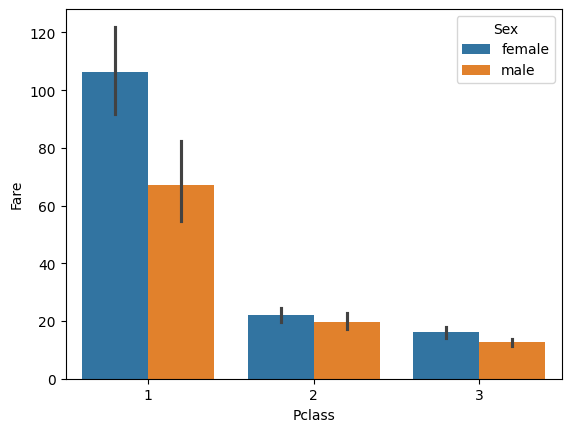

In [11]:
sns.barplot(x='Pclass',y='Fare',data=df,hue='Sex')

<Axes: xlabel='Survived', ylabel='Pclass'>

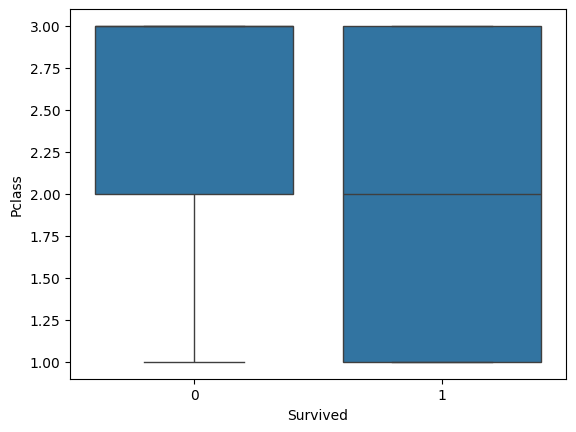

In [17]:
sns.boxplot(x='Survived', y='Pclass', data=df)

C:\Users\tyagi\AppData\Local\Temp\ipykernel_14948\455601345.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Age'],hist=False)
C:\Users\tyagi\AppData\Local\Temp\ipykernel_14948\455601345.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Surviv

<Axes: xlabel='Age', ylabel='Density'>

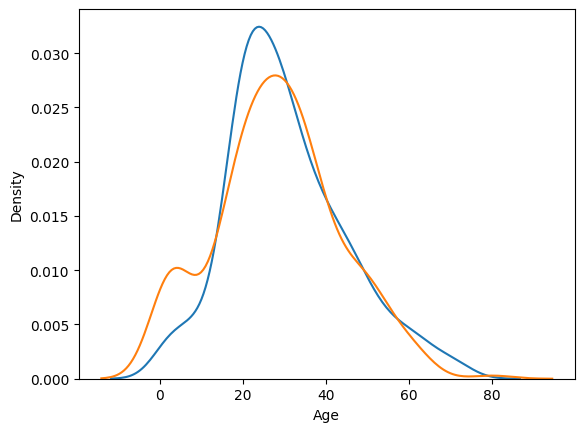

In [22]:
sns.distplot(df[df['Survived']==0]['Age'],hist=False)
sns.distplot(df[df['Survived']==1]['Age'],hist=False)

# Category vs category

In [28]:
pd.crosstab(df['Pclass'],df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

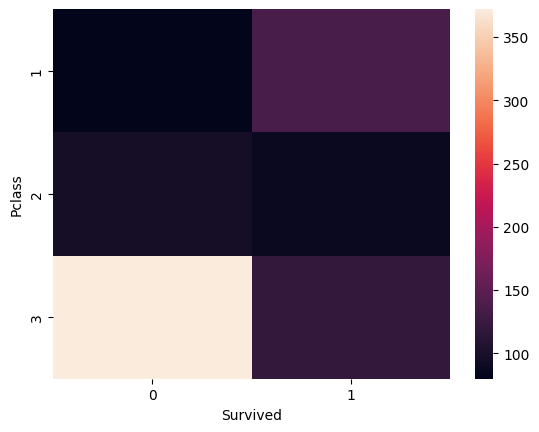

In [30]:
sns.heatmap(pd.crosstab(df['Pclass'],df['Survived']))

In [34]:
df.groupby('Pclass')['Survived'].mean()


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

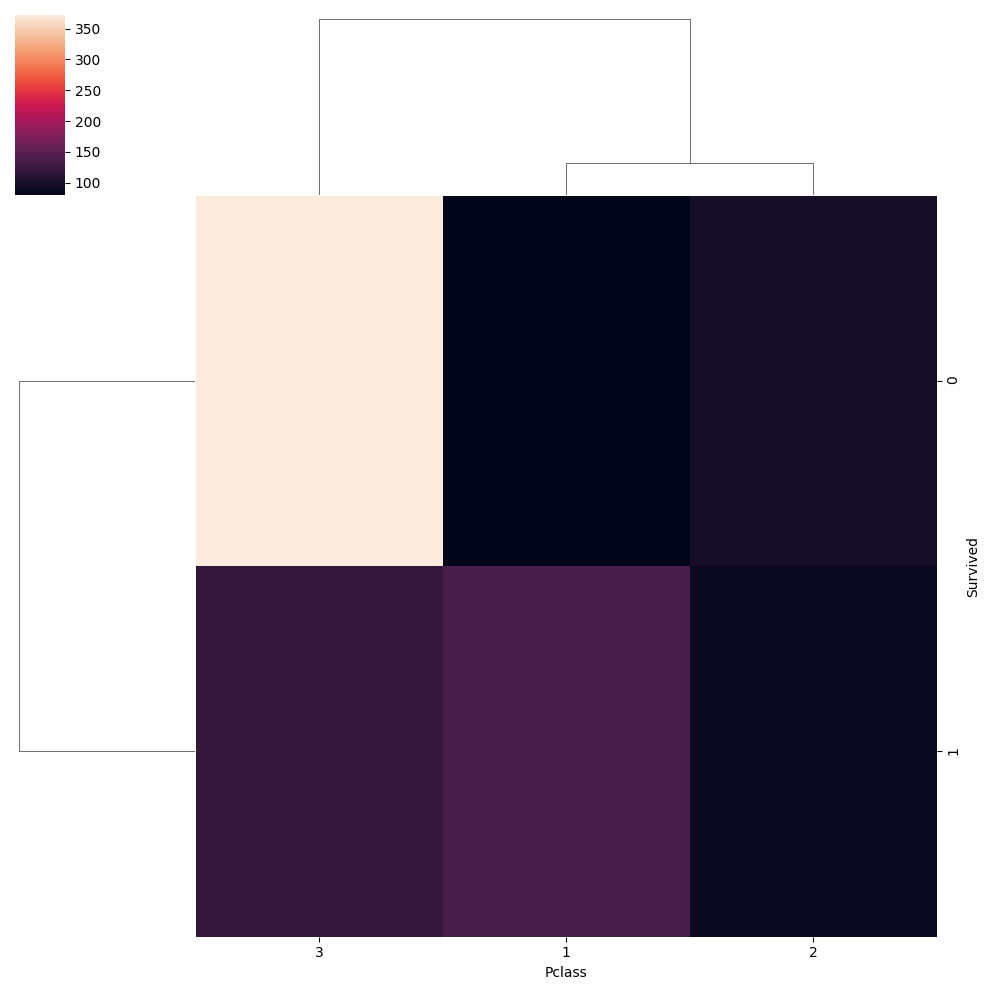

In [35]:
sns.clustermap(pd.crosstab(df['Survived'],df['Pclass']))

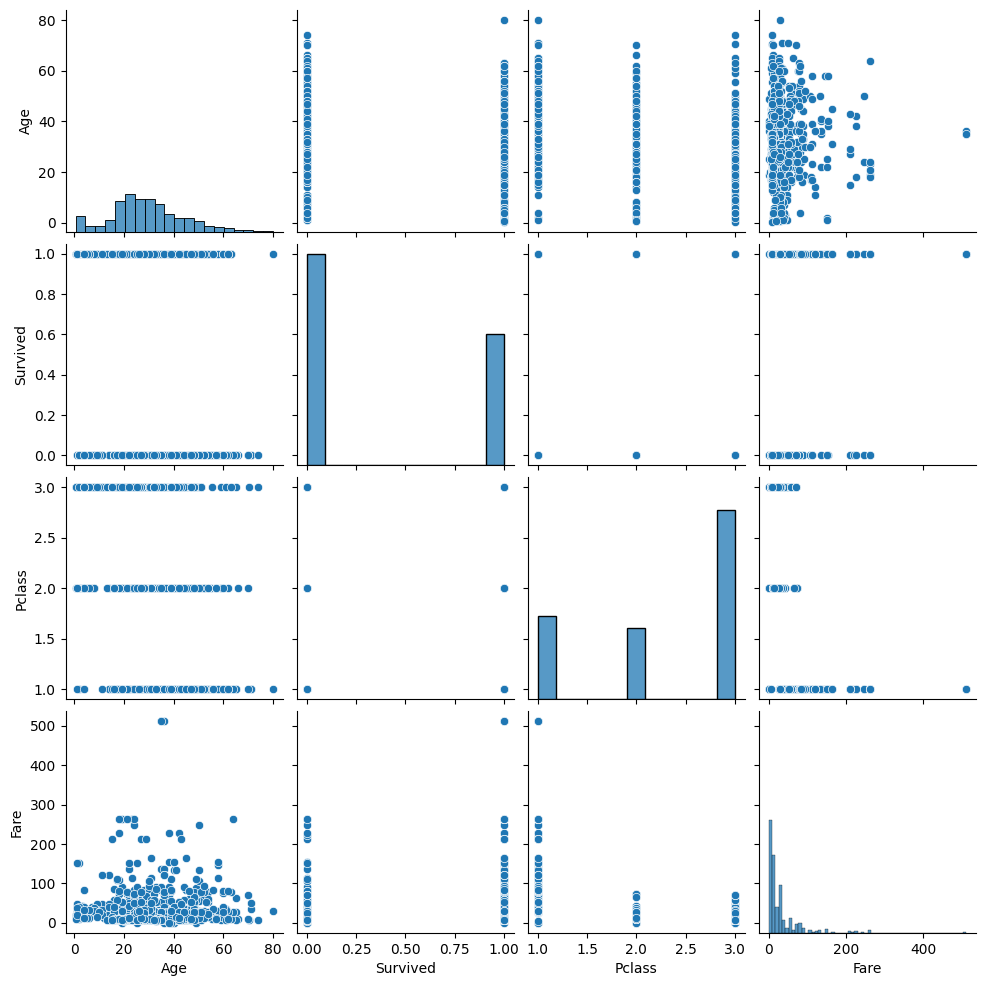

In [39]:
sns.pairplot(df[['Age','Survived','Pclass','Fare']])

In [49]:
new_data=flight.groupby('year')['passengers'].sum().reset_index()
new_data

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


<Axes: xlabel='year', ylabel='passengers'>

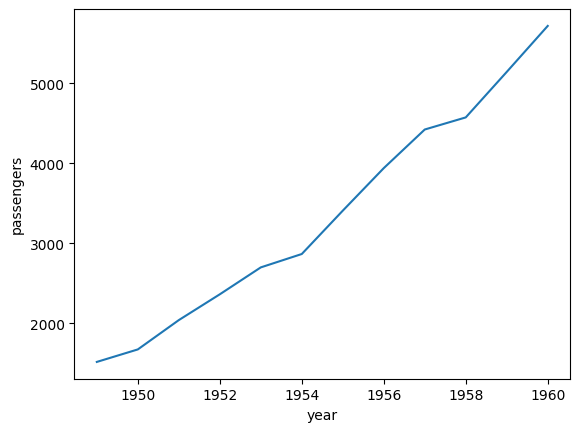

In [50]:
sns.lineplot(x='year',y='passengers',data=new_data)

C:\Users\tyagi\AppData\Local\Temp\ipykernel_14948\873118999.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(flight.pivot_table(values='passengers',index='month',columns='year'))


<Axes: xlabel='year', ylabel='month'>

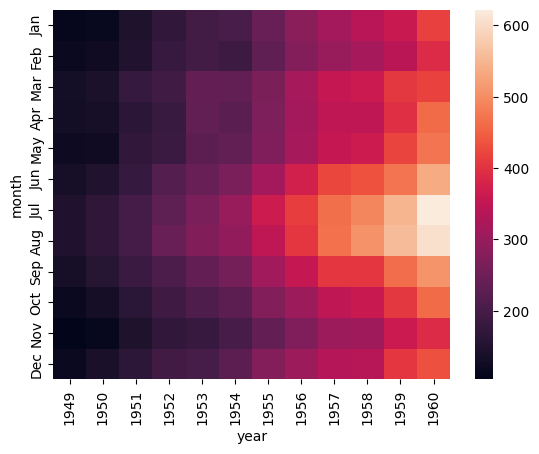

In [53]:
sns.heatmap(flight.pivot_table(values='passengers',index='month',columns='year'))

C:\Users\tyagi\AppData\Local\Temp\ipykernel_14948\3481122833.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(flight.pivot_table(values='passengers',index='month',columns='year'))


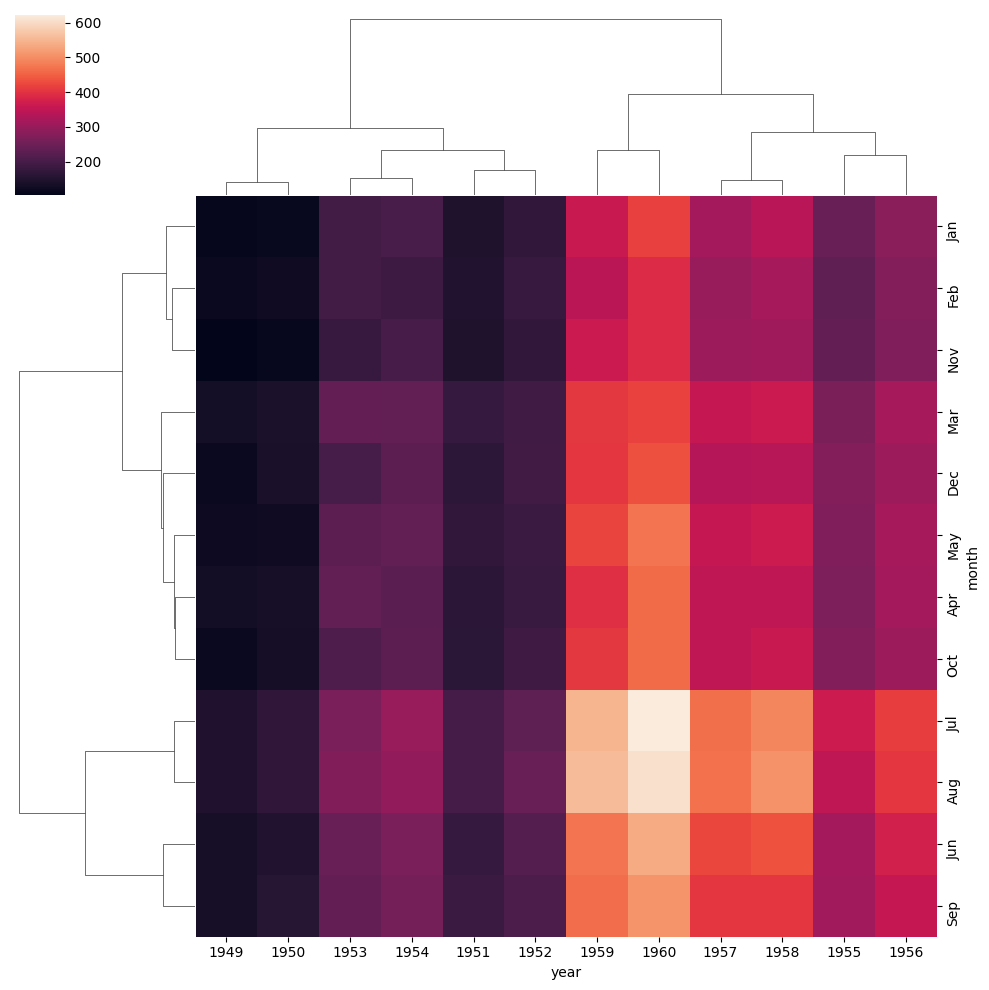

In [54]:
sns.clustermap(flight.pivot_table(values='passengers',index='month',columns='year'))